# FFTPSF Colour Fringe Analysis

This notebook demonstrates the FFT-based PSF route for computing colour fringe width (CFW).
For interactive comparison of analytic PSF models, see `cfw_demo.ipynb`.

In [1]:
# ───────────────────────────── Imports ─────────────────────────────
import gc
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Allow "import chromf …" without installing the package
sys.path.insert(0, str(Path("..").resolve() / "src"))

from chromf.spectrum_loader import channel_products
from chromf.optiland_bridge import compute_polychromatic_esf
from optiland import fileio
from optiland.physical_apertures import RadialAperture

FNO 1 = 2.0，focal length 1 = 85.00003717952896 mm


(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

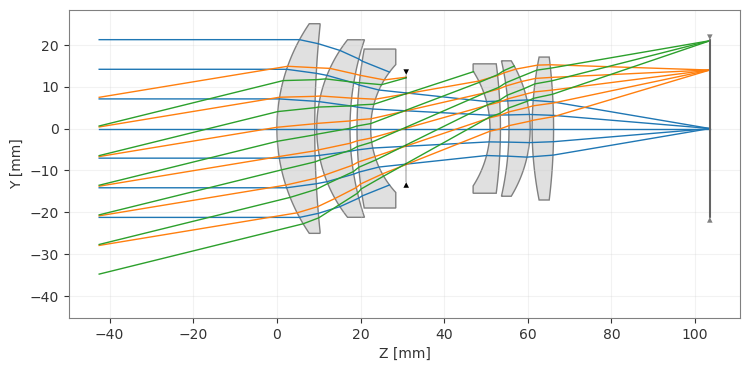

In [2]:
lens1 = fileio.load_zemax_file("C:\\Users\\meetf\\Downloads\\NikonAINikkor85mmf2S.zmx")
clear_semi_diameters = [
            None, 25.062, 24.642, 21.225, 21.225, 19.006, 15.289,
            12.836, 13.730, 15.469, 16.188, 16.188, 17.088, 17.088, 21.190
        ]
for i, r in enumerate(clear_semi_diameters):
            if r is not None:
                lens1.surface_group.surfaces[i].aperture = RadialAperture(r_max=r)
print(f"FNO 1 = {lens1.paraxial.FNO()}，focal length 1 = {lens1.paraxial.f2()} mm")
lens1.draw(num_rays=7)


In [3]:
# ──────────────────────────── Data load ────────────────────────────
prods = channel_products()
sensor_wl = prods["blue"][:, 0]   # nm
wl = sensor_wl

FN_DEFAULT = float(lens1.paraxial.FNO())
print(f"FNO = {FN_DEFAULT}, focal length = {lens1.paraxial.f2()} mm")

FNO = 2.0, focal length = 85.00003717952896 mm


In [4]:
# ──────────────────────────── Constants ─────────────────────────────
GAMMA_DEFAULT    = 2.2
COLOR_DIFF_THRESHOLD = 0.15

In [5]:
# ── FFTPSF: compute CFW inline, no ESF cache ─────────────────────────────────
# PSF grid parameters (num_rays=400, grid_size=512):
#   Q = 512 / 399 ≈ 1.28  (acceptable for |z| >> λ·FNO² ≈ 2 µm)
#   Valid defocus range (blue 400 nm): 0.40 × FNO² × (num_rays-1) = 638 µm > 600 µm ✓
#   Increase grid_size to 1024 (Q≈2.57) for accurate ESF near z=0.

_X_UM      = np.arange(-400, 401, dtype=float)   # 801 µm, 1 µm step
_NUM_RAYS  = 400
_GRID_SIZE = 512
_WL_STRIDE = 3
_STRATEGY  = "chief_ray"

_GAMMA_BAKE    = GAMMA_DEFAULT
_EXPOSURE_BAKE = 4.0
_THR_FFTPSF    = COLOR_DIFF_THRESHOLD

_Z_MIN_BAKE  = -800
_Z_MAX_BAKE  =  400
_Z_STEP_BAKE =   50
_z_bake = np.arange(_Z_MIN_BAKE, _Z_MAX_BAKE + _Z_STEP_BAKE, _Z_STEP_BAKE)


def _tone_map(esf: np.ndarray, gamma: float = _GAMMA_BAKE,
              exposure: float = _EXPOSURE_BAKE) -> np.ndarray:
    return (np.tanh(exposure * esf) / np.tanh(exposure)) ** gamma


_n = len(_z_bake)
_cfw_curve   = np.zeros(_n, dtype=np.int32)
_max_diff    = np.zeros(_n, dtype=np.float64)
_trans_width = {c: np.zeros(_n, dtype=np.int32) for c in ("R", "G", "B")}
_pair_diff   = {"R-G": np.zeros(_n), "R-B": np.zeros(_n), "G-B": np.zeros(_n)}

for _i, _z in enumerate(_z_bake):
    _esfs = {}
    for _c in ("R", "G", "B"):
        _raw = compute_polychromatic_esf(
            lens1, _c, float(_z), _X_UM,
            num_rays=_NUM_RAYS, grid_size=_GRID_SIZE,
            wl_stride=_WL_STRIDE, strategy=_STRATEGY,
        )
        _esfs[_c] = _tone_map(_raw)
        _trans_width[_c][_i] = int(np.sum((_raw > 0.05) & (_raw < 0.95)))
        del _raw; gc.collect()

    _pair_diff["R-G"][_i] = np.abs(_esfs["R"] - _esfs["G"]).max()
    _pair_diff["R-B"][_i] = np.abs(_esfs["R"] - _esfs["B"]).max()
    _pair_diff["G-B"][_i] = np.abs(_esfs["G"] - _esfs["B"]).max()
    _max_diff[_i] = max(_pair_diff["R-G"][_i], _pair_diff["R-B"][_i], _pair_diff["G-B"][_i])

    _fringed = (
        (np.abs(_esfs["R"] - _esfs["G"]) > _THR_FFTPSF)
        | (np.abs(_esfs["R"] - _esfs["B"]) > _THR_FFTPSF)
        | (np.abs(_esfs["G"] - _esfs["B"]) > _THR_FFTPSF)
    )
    _cfw_curve[_i] = int(_fringed.sum())

    print(f"[{_i+1:>2}/{_n}]  z={_z:+6.0f} µm  CFW={_cfw_curve[_i]:>3} µm  "
          f"R-G={_pair_diff['R-G'][_i]:.3f}  R-B={_pair_diff['R-B'][_i]:.3f}  "
          f"G-B={_pair_diff['G-B'][_i]:.3f}")
    del _esfs; gc.collect()

print(f"\nDone.  Max CFW = {_cfw_curve.max()} µm  at z = {_z_bake[_cfw_curve.argmax()]:+.0f} µm")

[ 1/25]  z=  -800 µm  CFW=  0 µm  R-G=0.120  R-B=0.089  G-B=0.031
[ 2/25]  z=  -750 µm  CFW=  0 µm  R-G=0.131  R-B=0.097  G-B=0.034
[ 3/25]  z=  -700 µm  CFW=  0 µm  R-G=0.145  R-B=0.108  G-B=0.037
[ 4/25]  z=  -650 µm  CFW= 16 µm  R-G=0.162  R-B=0.122  G-B=0.041
[ 5/25]  z=  -600 µm  CFW= 22 µm  R-G=0.183  R-B=0.141  G-B=0.046
[ 6/25]  z=  -550 µm  CFW= 23 µm  R-G=0.210  R-B=0.164  G-B=0.052
[ 7/25]  z=  -500 µm  CFW= 25 µm  R-G=0.238  R-B=0.187  G-B=0.060
[ 8/25]  z=  -450 µm  CFW= 26 µm  R-G=0.267  R-B=0.209  G-B=0.068
[ 9/25]  z=  -400 µm  CFW= 26 µm  R-G=0.295  R-B=0.228  G-B=0.076
[10/25]  z=  -350 µm  CFW= 27 µm  R-G=0.316  R-B=0.244  G-B=0.084
[11/25]  z=  -300 µm  CFW= 27 µm  R-G=0.326  R-B=0.256  G-B=0.087
[12/25]  z=  -250 µm  CFW= 27 µm  R-G=0.328  R-B=0.252  G-B=0.084
[13/25]  z=  -200 µm  CFW= 25 µm  R-G=0.321  R-B=0.244  G-B=0.088
[14/25]  z=  -150 µm  CFW= 19 µm  R-G=0.281  R-B=0.218  G-B=0.068
[15/25]  z=  -100 µm  CFW=  4 µm  R-G=0.163  R-B=0.162  G-B=0.014
[16/25]  z

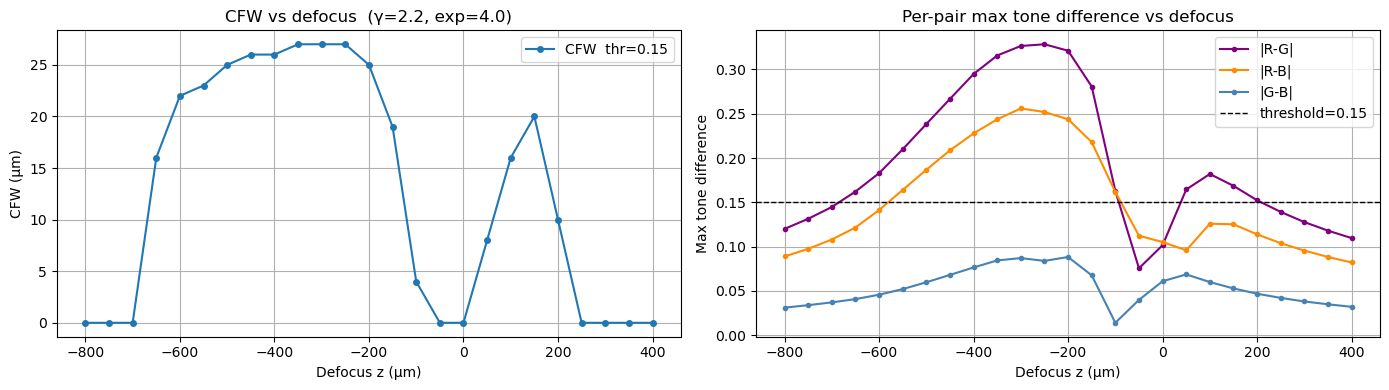

Max CFW: 27 µm  at z = -350 µm


In [6]:
# ── FFTPSF: CFW and per-pair max tone difference vs defocus ──────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(_z_bake, _cfw_curve, "o-", ms=4, label=f"CFW  thr={_THR_FFTPSF}")
ax1.set(title=f"CFW vs defocus  (γ={_GAMMA_BAKE}, exp={_EXPOSURE_BAKE})",
        xlabel="Defocus z (µm)", ylabel="CFW (µm)")
ax1.legend(); ax1.grid(True)

for _pair, _col in [("R-G", "purple"), ("R-B", "darkorange"), ("G-B", "steelblue")]:
    ax2.plot(_z_bake, _pair_diff[_pair], "o-", ms=3, color=_col, label=f"|{_pair}|")
ax2.axhline(_THR_FFTPSF, color="k", ls="--", lw=1, label=f"threshold={_THR_FFTPSF}")
ax2.set(title="Per-pair max tone difference vs defocus",
        xlabel="Defocus z (µm)", ylabel="Max tone difference")
ax2.legend(); ax2.grid(True)

plt.tight_layout(); plt.show()

print(f"Max CFW: {_cfw_curve.max()} µm  at z = {_z_bake[_cfw_curve.argmax()]:+.0f} µm")

       z   R_trans   G_trans   B_trans   max_diff    CFW
------------------------------------------------------------
    -800       301       270       280     0.1200      0
    -750       280       250       259     0.1314      0
    -700       260       229       238     0.1447      0
    -650       240       208       218     0.1621     16
    -600       220       188       198     0.1829     22
    -550       200       168       179     0.2098     23
    -500       182       150       160     0.2383     25
    -450       163       132       140     0.2667     26
    -400       144       116       123     0.2948     26
    -350       128       100       107     0.3157     27
    -300       112        84        92     0.3265     27
    -250        96        71        78     0.3284     27
    -200        82        58        64     0.3211     25
    -150        68        48        51     0.2807     19
    -100        56        44        44     0.1629      4
     -50        47        5

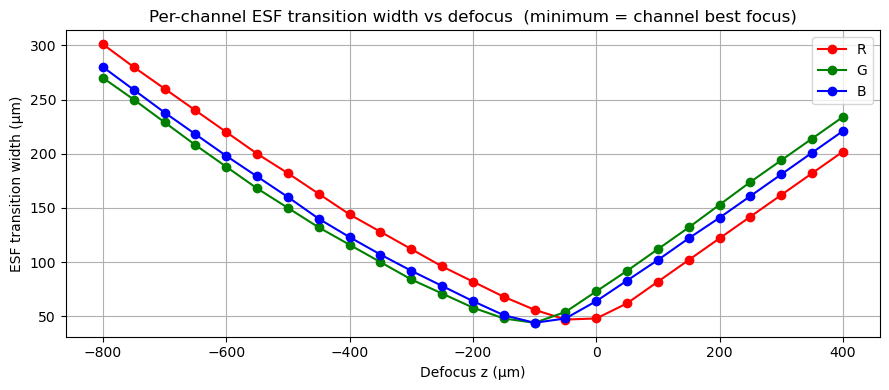

In [7]:
# ── ESF transition width vs defocus ──────────────────────────────────────────
print(f"{'z':>8}  {'R_trans':>8}  {'G_trans':>8}  {'B_trans':>8}  "
      f"{'max_diff':>9}  {'CFW':>5}")
print("-" * 60)
for _i, _z in enumerate(_z_bake):
    print(f"{_z:>8.0f}  "
          f"{_trans_width['R'][_i]:>8}  {_trans_width['G'][_i]:>8}  {_trans_width['B'][_i]:>8}  "
          f"{_max_diff[_i]:>9.4f}  {_cfw_curve[_i]:>5}")
print(f"\nMax diff = {_max_diff.max():.4f} at z = {_z_bake[_max_diff.argmax()]:+.0f} µm  "
      f"(threshold = {_THR_FFTPSF})")

plt.figure(figsize=(9, 4))
for _c, _col in [("R", "r"), ("G", "g"), ("B", "b")]:
    plt.plot(_z_bake, _trans_width[_c], "o-", color=_col, label=_c)
plt.xlabel("Defocus z (µm)")
plt.ylabel("ESF transition width (µm)")
plt.title("Per-channel ESF transition width vs defocus  (minimum = channel best focus)")
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

Label                                            CFW   max_diff   R_tr   G_tr   B_tr
--------------------------------------------------------------------------------
z=-350 / -CFW peak                                27     0.3157    128    100    107
z=-250 / max_diff peak                            27     0.3284     96     71     78
z=-100 / G best focus / B best focus               4     0.1629     56     44     44
z=-50 / R best focus                               0     0.1123     47     54     48
z=0 (nominal)                                      0     0.1052     48     73     64
z=+150 / +CFW peak                                20     0.1686    102    132    122
[1/6] computing z=-350 µm ...
[2/6] computing z=-250 µm ...
[3/6] computing z=-100 µm ...
[4/6] computing z=-50 µm ...
[5/6] computing z=+0 µm ...
[6/6] computing z=+150 µm ...


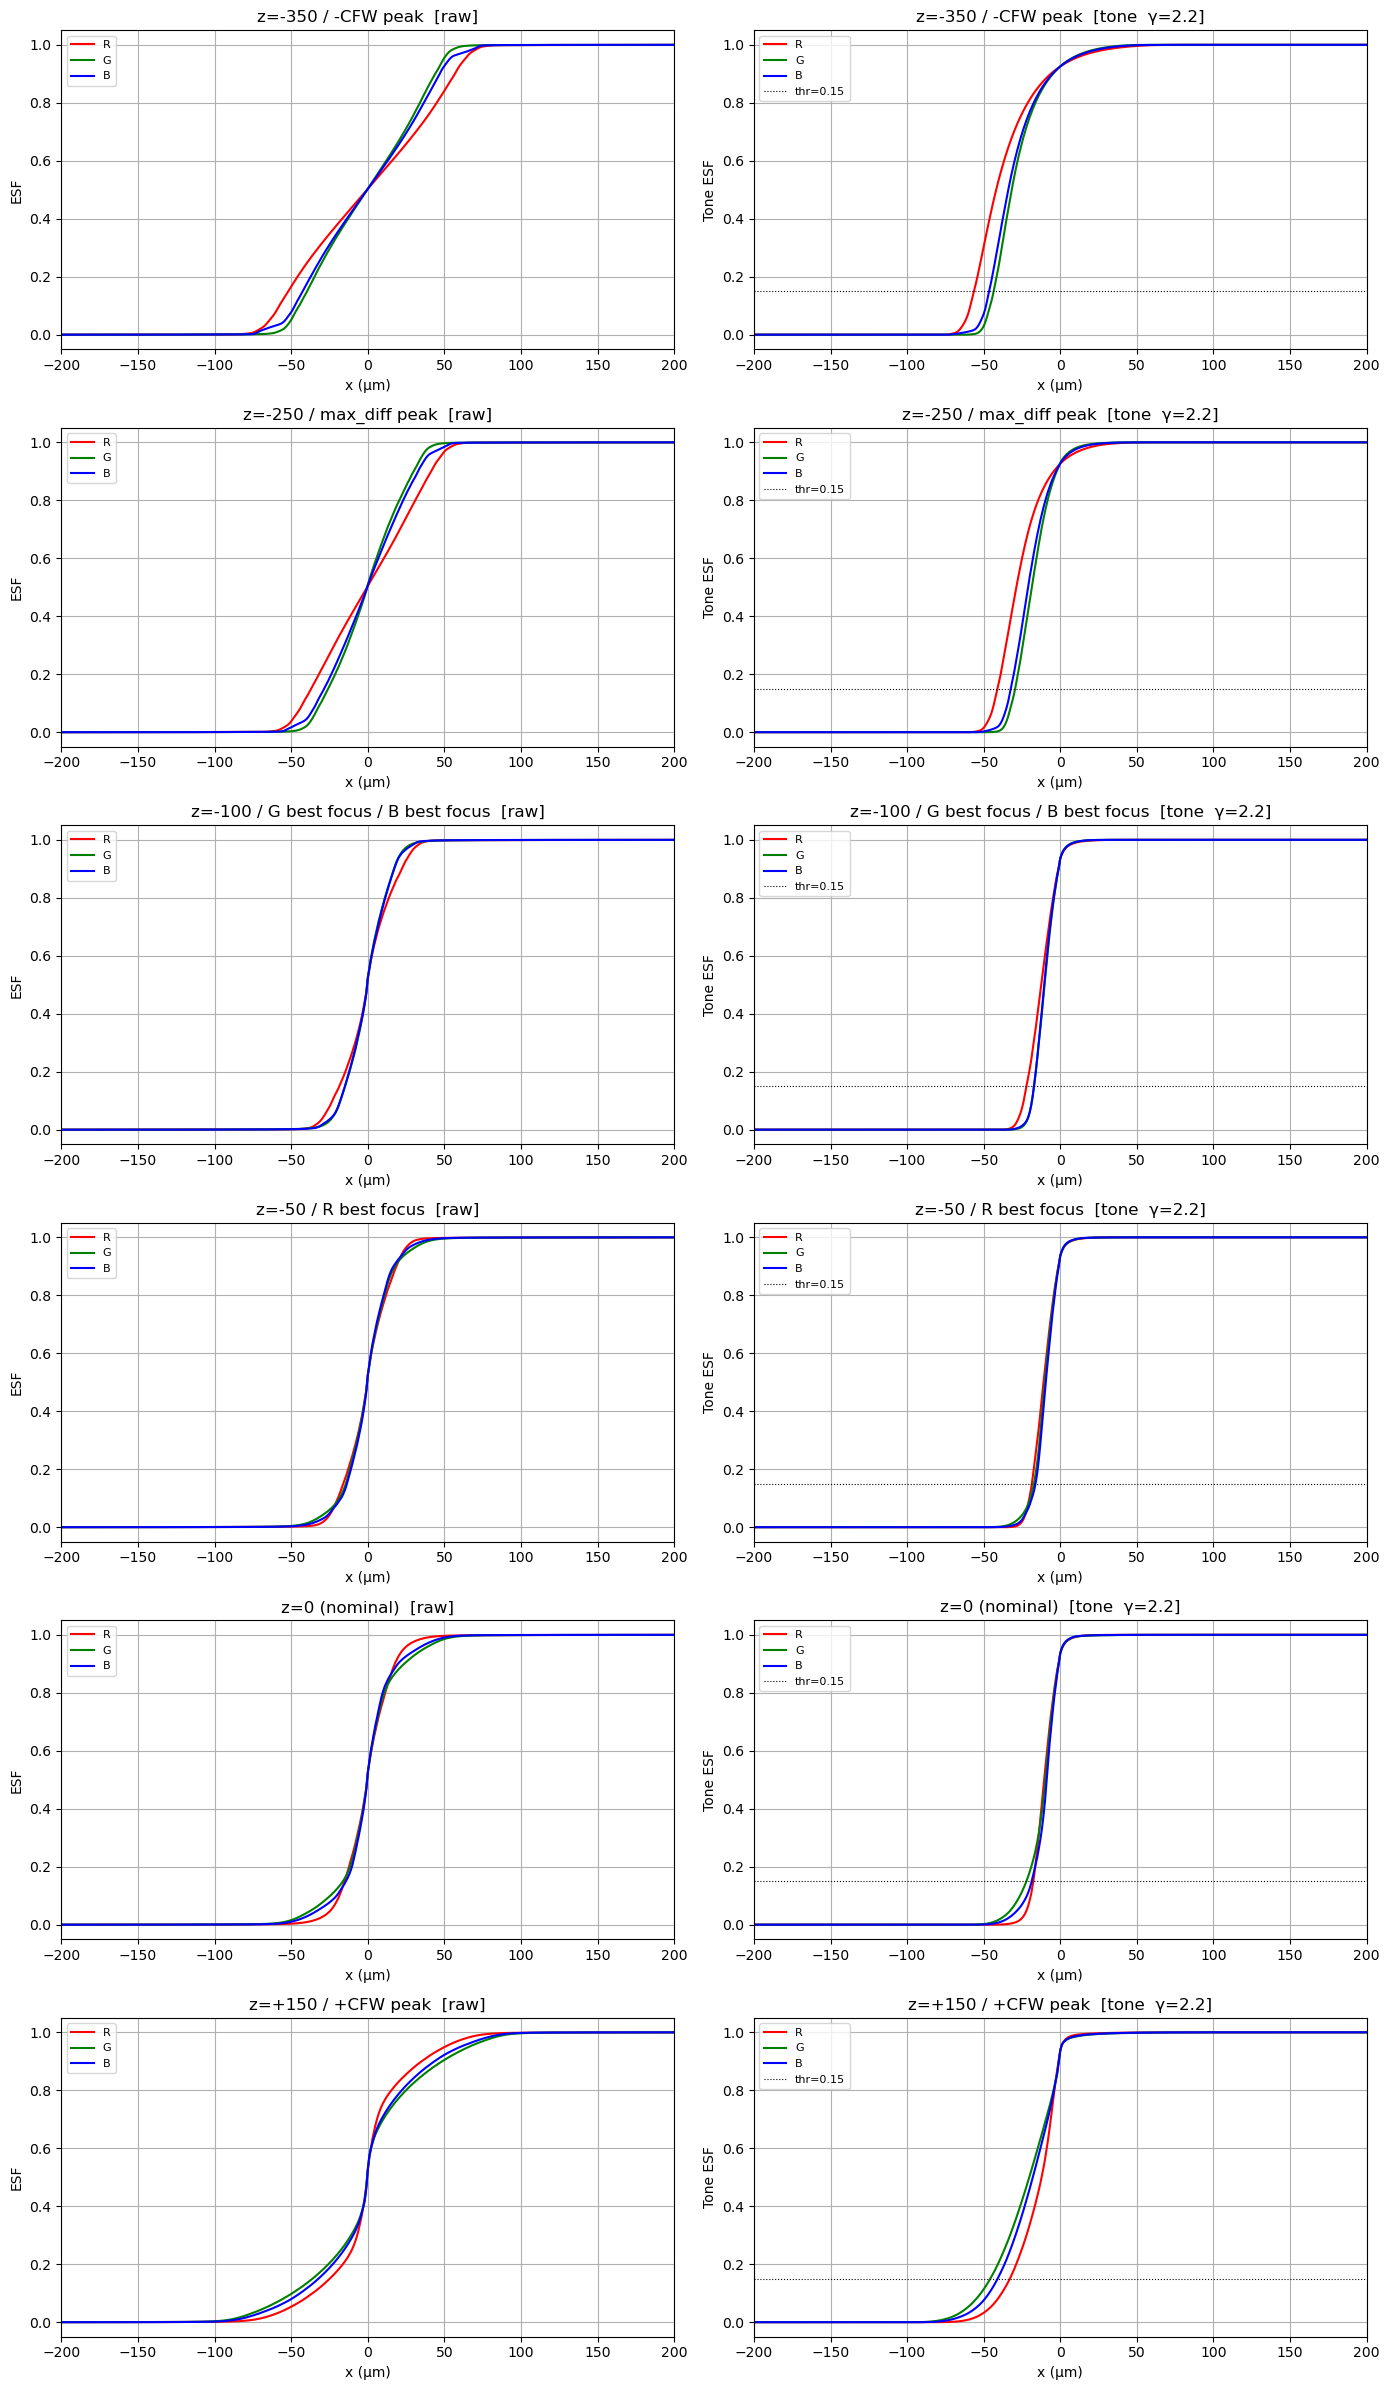

In [8]:
# ── ESF diagnostic: key defocus positions ────────────────────────────────────
# Key z values are selected automatically from bake results:
#   z=0, per-channel best focus (min transition width), ±CFW peaks, max_diff peak.

def _key_z_points() -> list[tuple[float, str]]:
    pts: dict[float, str] = {0.0: "z=0 (nominal)"}
    for _c in ("R", "G", "B"):
        _z = float(_z_bake[_trans_width[_c].argmin()])
        pts[_z] = pts.get(_z, f"z={_z:+.0f}") + f" / {_c} best focus"
    for _mask, _side in [(_z_bake > 0, "+CFW peak"), (_z_bake < 0, "-CFW peak")]:
        if _mask.any():
            _z = float(_z_bake[_mask][_cfw_curve[_mask].argmax()])
            pts[_z] = pts.get(_z, f"z={_z:+.0f}") + f" / {_side}"
    _z = float(_z_bake[_max_diff.argmax()])
    pts[_z] = pts.get(_z, f"z={_z:+.0f}") + " / max_diff peak"
    return sorted(pts.items())

_diag_points = _key_z_points()

print(f"{'Label':45s}  {'CFW':>5}  {'max_diff':>9}  {'R_tr':>5}  {'G_tr':>5}  {'B_tr':>5}")
print("-" * 80)
for _z, _lbl in _diag_points:
    _i = int(np.searchsorted(_z_bake, _z))
    print(f"{_lbl:45s}  {_cfw_curve[_i]:>5}  {_max_diff[_i]:>9.4f}  "
          f"{_trans_width['R'][_i]:>5}  {_trans_width['G'][_i]:>5}  {_trans_width['B'][_i]:>5}")

# Compute ESFs at each key point and plot
_n = len(_diag_points)
fig, _axes = plt.subplots(_n, 2, figsize=(14, 4 * _n), squeeze=False)
_xlim = (-200, 200)

for _row, (_z_val, _lbl) in enumerate(_diag_points):
    print(f"[{_row+1}/{_n}] computing z={_z_val:+.0f} µm ...")
    _raw, _tone_esf = {}, {}
    for _c in ("R", "G", "B"):
        _r = compute_polychromatic_esf(
            lens1, _c, float(_z_val), _X_UM,
            num_rays=_NUM_RAYS, grid_size=_GRID_SIZE,
            wl_stride=_WL_STRIDE, strategy=_STRATEGY,
        )
        _raw[_c] = _r
        _tone_esf[_c] = _tone_map(_r)
        del _r; gc.collect()

    for _c, _col in [("R", "r"), ("G", "g"), ("B", "b")]:
        _axes[_row, 0].plot(_X_UM, _raw[_c],      color=_col, label=_c, lw=1.5)
        _axes[_row, 1].plot(_X_UM, _tone_esf[_c], color=_col, label=_c, lw=1.5)
    _axes[_row, 0].set(title=f"{_lbl}  [raw]",
                       xlabel="x (µm)", ylabel="ESF", xlim=_xlim)
    _axes[_row, 1].set(title=f"{_lbl}  [tone  γ={_GAMMA_BAKE}]",
                       xlabel="x (µm)", ylabel="Tone ESF", xlim=_xlim)
    _axes[_row, 1].axhline(_THR_FFTPSF, color="k", ls=":", lw=0.8,
                           label=f"thr={_THR_FFTPSF}")
    for _ax in _axes[_row]:
        _ax.legend(fontsize=8); _ax.grid(True)

    del _raw, _tone_esf; gc.collect()

plt.tight_layout(); plt.show()